# Linear regression model

This file aims to predict the variable 'rate_avg' from the available features using a linear regression model. First, linear regression is performed without any feature selection. This gives us a baseline model we will use later for comparison. Second, ridge regression is performed and the model is evaluated. Finally, lasso regression provides us with a model in which some unimportant features have their coefficient being zeroed out. A comparison table at the end of this file summarizes the obtained results.

The following metrics are used to evaluate the different models:
- MSE: penalizes large errors
- MAE: direct representation of sum of error terms
- MAPE: percentage of true value y, shows 'how far the model is from actual values' <=> average relative error in %
- R^2: fraction of variance explained by the data

Due to the lack of adequate values in the dateset, the data can not be used as time series. Therefore, we chose to consider the points as being completely independent of time. Another choice could be to consider time series based on yearly division. 

### Outline :
The following processes will be applied with different types of feature selection:
1. split data
2. develop and fit the model
3. predict using the model + hyperparameter tuning with 5-fold CV
4. evaluate the model
5. bootstrap to get CI for coeffs and metrics

Types of feature selection to which the processes above will be applied:
- baseline model including all features
- ridge regression
- lasso regression

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
the_df=pd.read_csv('MSE446_cleaned_dataset_post_EDA.csv')
print(the_df.shape)
the_df.head()

(3225, 71)


,rate_avg,photos_count,superhost,latitude,longitude,guests,bedrooms,beds,baths,min_nights,...,listing_type_Private room in loft,listing_type_Private room in rental unit,listing_type_Private room in townhouse,room_type_private_room,cancellation_policy_Flexible,cancellation_policy_Limited,cancellation_policy_Moderate,cancellation_policy_Strict,cancellation_policy_Super Strict 30 Days,avg_temp
0,36.3,7,1,43.6483,-79.4012,1,1,1,0.0,31,...,0,0,1,1,0,0,1,0,0,-3.925
1,35.5,7,1,43.6483,-79.4012,1,1,1,0.0,31,...,0,0,1,1,0,0,1,0,0,0.770
2,35.9,7,1,43.6483,-79.4012,1,1,1,0.0,31,...,0,0,1,1,0,0,1,0,0,7.040
3,36.0,7,1,43.6483,-79.4012,1,1,1,0.0,31,...,0,0,1,1,0,0,1,0,0,13.890
4,36.5,7,1,43.6483,-79.4012,1,1,1,0.0,31,...,0,0,1,1,0,0,1,0,0,19.470


In [3]:
mse_compare=[]
mae_compare=[]
mape_compare=[]
r2_compare=[]

We first start with a baseline model that uses all available features from the dataset. 

## Baseline model

Split the data to define the training and the test set.

In [4]:
from sklearn.model_selection import train_test_split

X = the_df.drop(columns=['rate_avg']) #select all columns except 'rate_avg'
print(X.shape)
y=the_df['rate_avg']

X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=156)
print('\n'+str(X_train.shape))
print(X_test.shape)
print(y_train.shape)

print(y_test.shape)

(3225, 70)

(2580, 70)
(645, 70)
(2580,)
(645,)


In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# Create and fit the model
from sklearn.linear_model import LinearRegression

lm = LinearRegression()
lm.fit(X_train_scaled, y_train)

LinearRegression()

In [7]:
# Print the parameters of the model
print(lm.intercept_)
#print(lm.coef_)
coef_df = pd.DataFrame(lm.coef_, X.columns, columns=['Coefficient'])
print(coef_df.sort_values(by='Coefficient', ascending=False))

127.52099618013258
                                           Coefficient
listing_type_Private room in home         3.073216e+13
is_summer                                 2.844113e+13
Revenue_Per_Available_Room                2.427667e+13
listing_type_Private room in rental unit  1.839669e+13
is_fall                                   1.434595e+13
...                                                ...
is_august                                -2.383743e+13
is_february                              -2.475396e+13
is_june                                  -3.410755e+13
Average_Daily_Rate                       -3.524385e+13
room_type_private_room                   -3.712178e+13

[70 rows x 1 columns]


The baseline coefficients are very large (on the order of 10^13), which is a sign of numerical instability due to multicollinearity in the feature set. Using ridge and lasso regression constitutes a possible solution to this problem, since these methods reduce or even zero out some feature coefficients.

Predict with the model and output the following metrics: MAE, MSE, MAPE, R^2. Plot the predicted values vs the true values for 'rate_avg'.

MAE:  40.77561690478571
MSE:  3154.4769959168366
MAPE:  0.4301126727104253
R^2:  0.7100724735309689


Text(0.5, 1.0, 'Residual Plot')

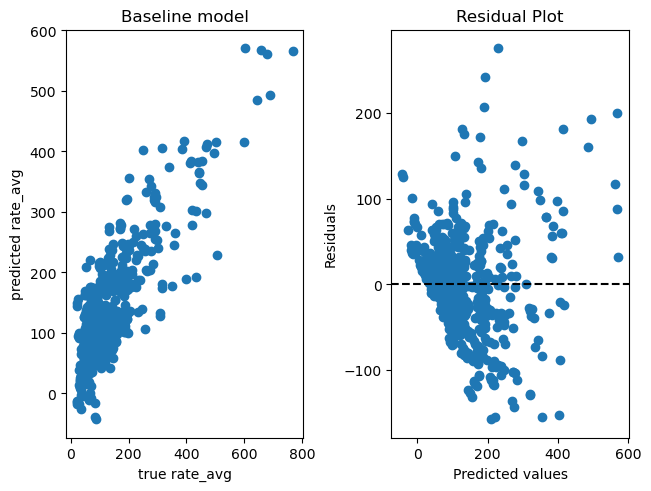

In [8]:
predictions = lm.predict(X_test_scaled)

from sklearn import metrics
print('MAE: ', metrics.mean_absolute_error(y_test, predictions))
print('MSE: ', metrics.mean_squared_error(y_test, predictions))
print('MAPE: ', metrics.mean_absolute_percentage_error(y_test, predictions))

from sklearn.metrics import r2_score

print('R^2: ', r2_score(y_test, predictions))

mae_compare.append(metrics.mean_absolute_error(y_test, predictions))
mse_compare.append(metrics.mean_squared_error(y_test, predictions))
mape_compare.append(metrics.mean_absolute_percentage_error(y_test, predictions))
r2_compare.append(metrics.r2_score(y_test, predictions))

fig, axs=plt.subplots(1, 2, layout="constrained")
axs[0].scatter(y_test, predictions)
axs[0].set_title('Baseline model')
axs[0].set_xlabel('true rate_avg')
axs[0].set_ylabel('predicted rate_avg')

residuals = y_test - predictions
axs[1].scatter(predictions, residuals)
axs[1].axhline(0, linestyle='--', color='black')
axs[1].set_xlabel('Predicted values')
axs[1].set_ylabel('Residuals')
axs[1].set_title('Residual Plot')

As can be seen, this baseline model performs moderately well. The MSE is large, indicating that some points are predicted with a large error. An R^2  value of 0.71 means that only 71% of variance in the predicted data can actually be explained by the model. The large residuals and high MAPE show that the model lacks precision when predicting the target variable.

## Ridge regression

We will now follow the same procedure, but will use this time ridge regression to shrink the coefficients of some features to reduce the impact of multicollinearity. As a reminder, ridge regression keeps all features but tries to stabilize the model. 

In [9]:
#delete same-named variables:
del X, y, X_train, X_test, y_train, y_test, predictions

We start by splitting the data into training and test sets.

In [10]:
from sklearn.model_selection import train_test_split

X = the_df.drop(columns=['rate_avg']) #select all columns except 'rate_avg'
print(X.shape)
y=the_df['rate_avg']

X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=156)
print('\n'+str(X_train.shape))
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(3225, 70)

(2580, 70)
(645, 70)
(2580,)
(645,)


Then, we fit the model and perform hyperparameter tuning (using 5-fold Cross Validation) to find the best alpha value for the ridge regression model:

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

#scale features, initiate model, use GridSearchCV, search for the best penality alpha between 0.1 and 5
pipe = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge())])
params = {'ridge__alpha': np.linspace(0.1, 5, 100)}
grid_ridge = GridSearchCV(pipe, params, scoring='neg_mean_absolute_error', cv=5)

grid_ridge.fit(X_train, y_train) #fit the function to train set 

# Find the best parameter and see how well it performs on test set
print(grid_ridge.best_params_)
best_scaler = grid_ridge.best_estimator_.named_steps['scaler']
best_alpha=float(grid_ridge.best_params_['ridge__alpha'])
print(grid_ridge.score(X_test, y_test))
#print(grid_ridge.cv_results_['mean_test_score'])

X_train_scaled = best_scaler.transform(X_train)
X_test_scaled  = best_scaler.transform(X_test)

{'ridge__alpha': 3.9606060606060614}
-40.76968131802209


Now, let's evaluate the model. It uses the optimal alpha (ridge's penality coefficient) found through hyperparameter tuning. 

MAE:  40.76968131802209
MSE:  3153.982628801015
MAPE:  0.4270051098836705
R^2:  0.7101179107413983
Max Error: 276.0933501642704
Median Absolute Error: 29.386804781601413


Text(0.5, 1.0, 'Q-Q Plot of Residuals')

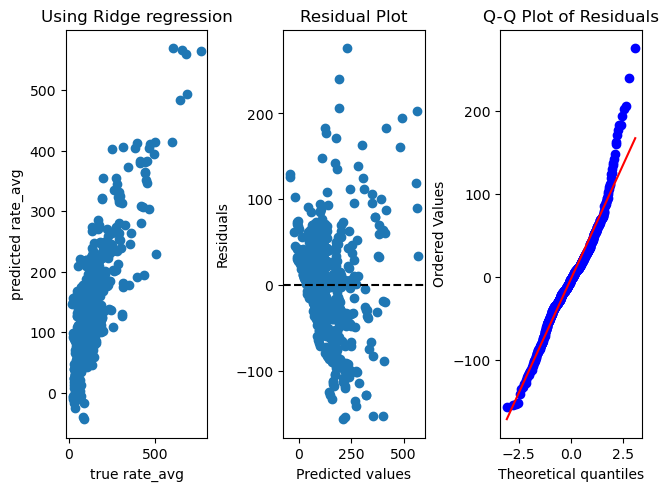

In [12]:
predict = grid_ridge.best_estimator_.predict(X_test)

from sklearn import metrics

print('MAE: ', metrics.mean_absolute_error(y_test, predict))
print('MSE: ', metrics.mean_squared_error(y_test, predict))
print('MAPE: ', metrics.mean_absolute_percentage_error(y_test, predict))
print('R^2: ', metrics.r2_score(y_test, predict))
print('Max Error:', metrics.max_error(y_test, predict))
print('Median Absolute Error:', metrics.median_absolute_error(y_test, predict)) #more robust to outliers than mean

mae_compare.append(metrics.mean_absolute_error(y_test, predict))
mse_compare.append(metrics.mean_squared_error(y_test, predict))
mape_compare.append(metrics.mean_absolute_percentage_error(y_test, predict))
r2_compare.append(metrics.r2_score(y_test, predict))

fig, axs=plt.subplots(1, 3, layout="constrained")
axs[0].scatter(y_test, predict)
axs[0].set_title('Using Ridge regression')
axs[0].set_xlabel('true rate_avg')
axs[0].set_ylabel('predicted rate_avg')

residuals = y_test - predict
axs[1].scatter(predict, residuals)
axs[1].axhline(0, linestyle='--', color='black')
axs[1].set_xlabel('Predicted values')
axs[1].set_ylabel('Residuals')
axs[1].set_title('Residual Plot')

import scipy.stats as stats
stats.probplot(residuals, dist="norm", plot=axs[2])
axs[2].set_title('Q-Q Plot of Residuals') #values following red line = residuals are normally distributed (=assumption of lin reg)

The first plot shows the predicted vs the true values. The second displays the behavior of the residuals vs the predicted values. Despite using ridge regression, it can be observed that some predicted values have a large error, leading to a high MSE value. The Quantile-Quantile residual plot helps verifying if the residuals follow a normal distribution. It can be seen that this is not exactly the case, meaning that linear regression may not be the best model to predict the values of 'rate_avg'.

Finally, we use bootstrap on the training set to find confidence intervals for the coefficients and the metrics.

In [13]:
from sklearn.utils import resample
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import r2_score

score_mse = []
score_mae = []
score_mape = []
score_r2 = []
n_iterations = 1000
coef_list = []

for i in range(n_iterations):
    # resample the TRAINING set, keep test set fixed
    X_boot, y_boot = resample(X_train_scaled, y_train, replace=True)
    
    #refit model on each bootstrap sample
    model_boot = Ridge(alpha=best_alpha)
    model_boot.fit(X_boot, y_boot)
    
    #evaluate on FIXED test set
    predict = model_boot.predict(X_test_scaled)
    curr_score_mse = mean_squared_error(y_test, predict, squared=True)  #MSE
    curr_score_mae = mean_absolute_error(y_test, predict) #MAE
    curr_score_mape = mean_absolute_percentage_error(y_test, predict) #MAPE
    curr_score_r2 = r2_score(y_test, predict) #R^2
    score_mse.append(curr_score_mse)
    score_mae.append(curr_score_mae)
    score_mape.append(curr_score_mape)
    score_r2.append(curr_score_r2)
    
    #collect coeffs
    coef_list.append(model_boot.coef_) 
    
coef_array = np.array(coef_list)  #shape:(1000, n_features)
for j, col in enumerate(X.columns):
    lo = np.percentile(coef_array[:, j], 2.5)
    hi = np.percentile(coef_array[:, j], 97.5)
    print(f'{col:30s}: 95% CI [{lo:.3f}, {hi:.3f}]')  #if CI crosses 0 --> unstable feature    
       
median_mse = np.median(score_mse)
lower_mse  = np.percentile(score_mse, 2.5)
upper_mse  = np.percentile(score_mse, 97.5)

median_mae = np.median(score_mae)
lower_mae  = np.percentile(score_mae, 2.5)
upper_mae  = np.percentile(score_mae, 97.5)

median_mape = np.median(score_mape)
lower_mape  = np.percentile(score_mape, 2.5)
upper_mape  = np.percentile(score_mape, 97.5)

median_r2 = np.median(score_r2)
lower_r2  = np.percentile(score_r2, 2.5)
upper_r2  = np.percentile(score_r2, 97.5)

#for coefficients (not for results):
#the further from 0 is the CI, the better
#the smaller the CI, the better
print(f'\nMedian MSE: {median_mse:.2f}, 95% CI: [{lower_mse:.2f}, {upper_mse:.2f}]')
print(f'Median MAE: {median_mae:.2f}, 95% CI: [{lower_mae:.2f}, {upper_mae:.2f}]')
print(f'Median MAPE: {median_mape:.2f}, 95% CI: [{lower_mape:.2f}, {upper_mape:.2f}]')
print(f'Median R^2: {median_r2:.2f}, 95% CI: [{lower_r2:.2f}, {upper_r2:.2f}]')

photos_count                  : 95% CI [-1.901, 5.180]
superhost                     : 95% CI [-5.307, -0.482]
latitude                      : 95% CI [-1.009, 6.192]
longitude                     : 95% CI [3.602, 8.183]
guests                        : 95% CI [6.331, 20.307]
bedrooms                      : 95% CI [32.695, 46.382]
beds                          : 95% CI [0.926, 9.378]
baths                         : 95% CI [23.265, 39.055]
min_nights                    : 95% CI [-19.073, -13.259]
cleaning_fee                  : 95% CI [7.784, 14.217]
extra_guest_fee               : 95% CI [-2.627, 0.485]
num_reviews                   : 95% CI [6.661, 11.534]
rating_overall                : 95% CI [61.430, 98.276]
rating_accuracy               : 95% CI [-44.181, -14.655]
rating_checkin                : 95% CI [-48.229, -14.906]
rating_cleanliness            : 95% CI [-15.436, 5.907]
rating_communication          : 95% CI [-3.267, 28.266]
rating_location               : 95% CI [22.132, 38.6

Text(0.5, 1.0, 'R^2')

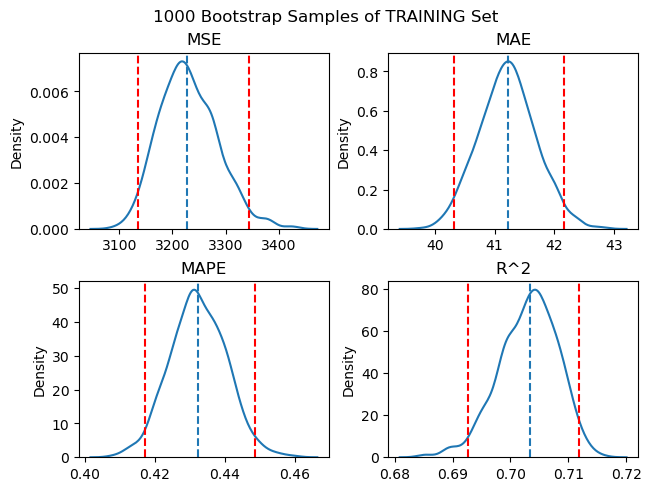

In [14]:
fig, axs = plt.subplots(2, 2, layout="constrained")
fig.suptitle('1000 Bootstrap Samples of TRAINING Set')
#MSE
sns.kdeplot(score_mse, ax=axs[0, 0])
axs[0, 0].axvline(median_mse, linestyle="--")
axs[0, 0].axvline(lower_mse, linestyle="--", color="red")
axs[0, 0].axvline(upper_mse, linestyle="--", color="red")
axs[0, 0].set_title('MSE')
#MAE
sns.kdeplot(score_mae, ax=axs[0, 1])
axs[0, 1].axvline(median_mae, linestyle="--")
axs[0, 1].axvline(lower_mae, linestyle="--", color="red")
axs[0, 1].axvline(upper_mae, linestyle="--", color="red")
axs[0, 1].set_title('MAE')
#MAPE
sns.kdeplot(score_mape, ax=axs[1, 0])
axs[1, 0].axvline(median_mape, linestyle="--")
axs[1, 0].axvline(lower_mape, linestyle="--", color="red")
axs[1, 0].axvline(upper_mape, linestyle="--", color="red")
axs[1, 0].set_title('MAPE')
#R^2
sns.kdeplot(score_r2, ax=axs[1, 1])
axs[1, 1].axvline(median_r2, linestyle="--")
axs[1, 1].axvline(lower_r2, linestyle="--", color="red")
axs[1, 1].axvline(upper_r2, linestyle="--", color="red")
axs[1, 1].set_title('R^2')

Text(0.5, 1.0, 'Coefficient estimates with 95% CI')

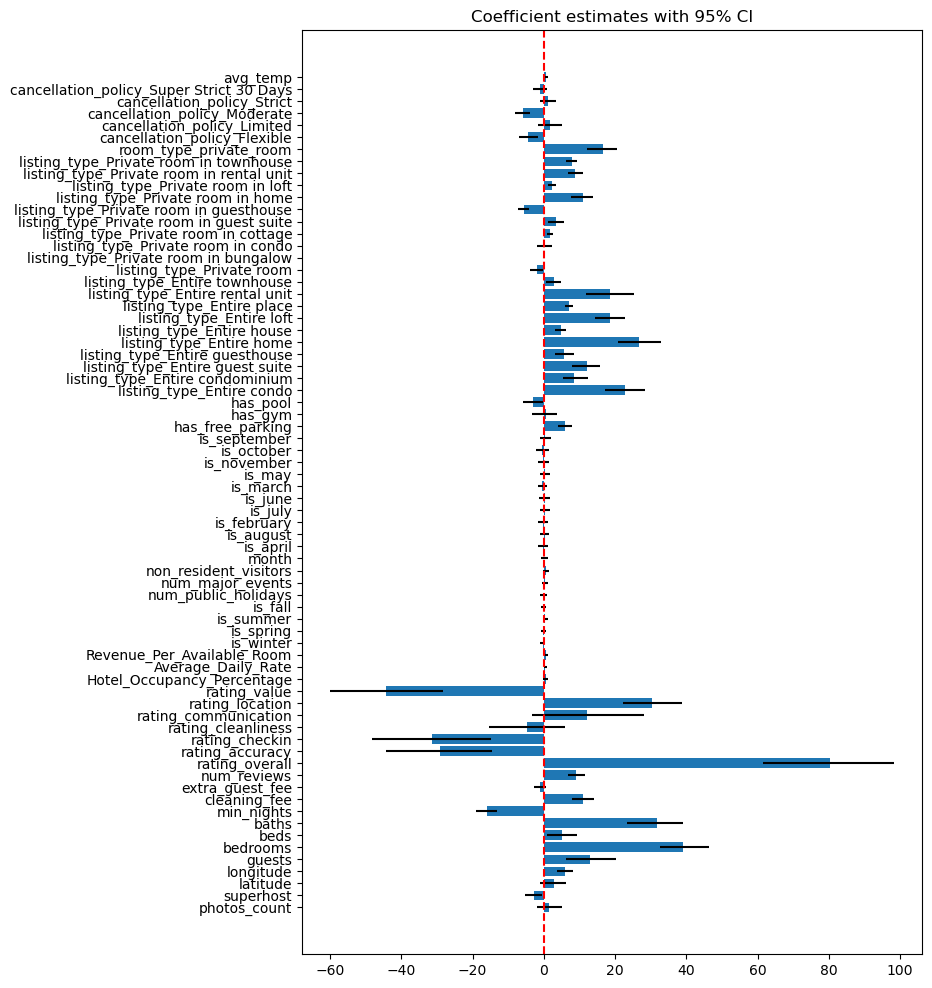

In [15]:
#coeff plot --> visualize bootstrap coefficient CIs
coef_array=np.array(coef_list)
means = coef_array.mean(axis=0)
lows  = np.percentile(coef_array,2.5,  axis=0)
highs = np.percentile(coef_array, 97.5, axis=0)

plt.figure(figsize=(8, 12))
plt.barh(X.columns, means, xerr=[means-lows, highs-means])
plt.axvline(0, linestyle='--', color='red')
plt.title('Coefficient estimates with 95% CI')
#features whose CI crosses 0 = unstable/unreliable

The CV learning curves display, for the training set error and the validation set error, the MAE vs the amount of training data that the training set is allowed to see. As can be seen, a small training set seems to lead to overfitting, but this problem is solved as the size of the training set increases. 

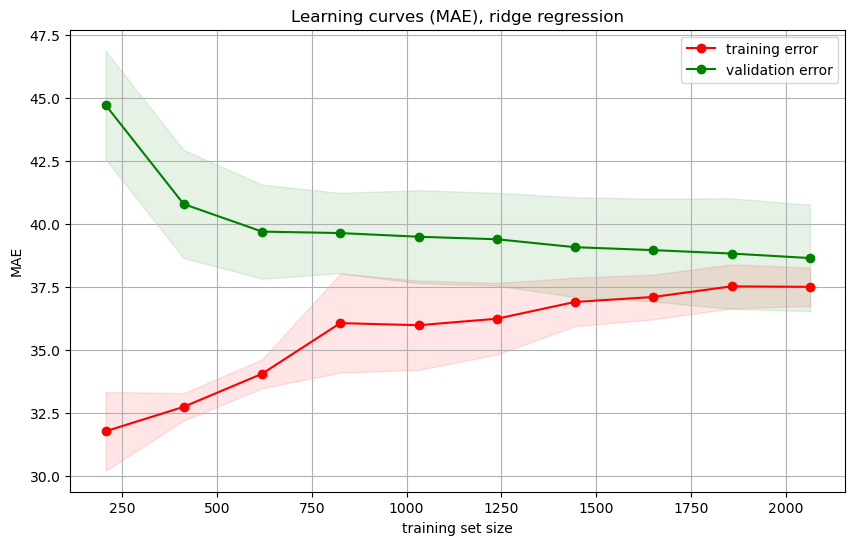

In [16]:
#CV learning curves: whether underfitting or overfitting + if more data would help
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    pipe, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='neg_mean_absolute_error', cv=5
)
train_errors = -train_scores.mean(axis=1)
val_errors = -val_scores.mean(axis=1)

train_std = train_scores.std(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(10, 6))

plt.plot(train_sizes, train_errors, 'o-', color="r", label="training error")
plt.plot(train_sizes, val_errors, 'o-', color="g", label="validation error")

plt.fill_between(train_sizes, train_errors - train_std, train_errors + train_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, val_errors - val_std, val_errors + val_std, alpha=0.1, color="g")

plt.title("Learning curves (MAE), ridge regression")
plt.xlabel("training set size")
plt.ylabel("MAE")
plt.legend(loc="best")
plt.grid(True)
plt.show()

## Lasso regression

We will now follow the same procedure, but will use this time lasso regression to zero out the coefficients of the least important features. Lasso automatically picks one feature from a correlated pair and zeroes out the other.

In [17]:
#delete same-named variables:
del X_train, X_test, y_train, y_test, coef_list, predict, coef_array

We start with the usual train-test split.

In [18]:
from sklearn.model_selection import train_test_split
 
X = the_df.drop(columns=['rate_avg']) #select all columns except 'rate_avg'
print(X.shape)
y = the_df['rate_avg']
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=156)
print('\n'+str(X_train.shape))
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(3225, 70)

(2580, 70)
(645, 70)
(2580,)
(645,)


Then, we perform hyperparameter tuning to find the best alpha (penalty coefficient of lasso regression model) by using 5-fold Cross Validation. These lines are relatively time consuming when searching over a broad range of values, so the results of former executions are commented below. An appropriate value for alpha was iteratively searched (starting with [0.01, 1.0]) to obtain the narrow interval that allows to get a precise value as shown below. 

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso 
from sklearn.model_selection import GridSearchCV
 
# Scale features, initiate model, use GridSearchCV, search for the best penalty alpha
pipe = Pipeline([('scaler', StandardScaler()), ('lasso', Lasso(max_iter=100000))])  
params = {'lasso__alpha': np.linspace(0.035, 0.036, 10)}

# Possible regression metrics to use:
# neg_mean_squared_error (MSE)
# neg_mean_absolute_error (MAE)
# r2 (R-squared)
grid_lasso = GridSearchCV(pipe, params, scoring='neg_mean_absolute_error', cv=5)
grid_lasso.fit(X_train, y_train)
 
# Find the best parameter and see how well it performs on test set
print(grid_lasso.best_params_)
best_scaler = grid_lasso.best_estimator_.named_steps['scaler']
best_alpha = float(grid_lasso.best_params_['lasso__alpha'])
print(grid_lasso.score(X_test, y_test))
 
X_train_scaled = best_scaler.transform(X_train)
X_test_scaled  = best_scaler.transform(X_test)

#results of former executions:
#{'lasso__alpha': 0.046415888336127774}
#-40.75628578796824
#{'lasso__alpha': 0.035}
#-40.74154014859792
#{'lasso__alpha': 0.035555555555555556}
#-40.741929929187094
#{'lasso__alpha': 0.035666666666666666}

{'lasso__alpha': 0.035666666666666666}
-40.742007331418485


Using the obtained alpha, the model can now predict the values for 'rate_avg'. The resulting metrics, as well as the features whose coefficient was put to zero by lasso regression are displayed below. 

MAE:  40.742007331418485
MSE:  3154.115132740759
MAPE:  0.4277186461875539
R^2:  0.7101057323233761
Max Error: 275.8970374374409
Median Absolute Error: 29.482666080793976

Features put to 0 by Lasso (17): ['Hotel_Occupancy_Percentage', 'Revenue_Per_Available_Room', 'is_winter', 'is_spring', 'is_summer', 'is_fall', 'num_public_holidays', 'non_resident_visitors', 'is_august', 'is_february', 'is_july', 'is_june', 'is_november', 'is_september', 'listing_type_Private room in bungalow', 'listing_type_Private room in home', 'listing_type_Private room in loft']


Text(0.5, 1.0, 'Q-Q Plot of Residuals')

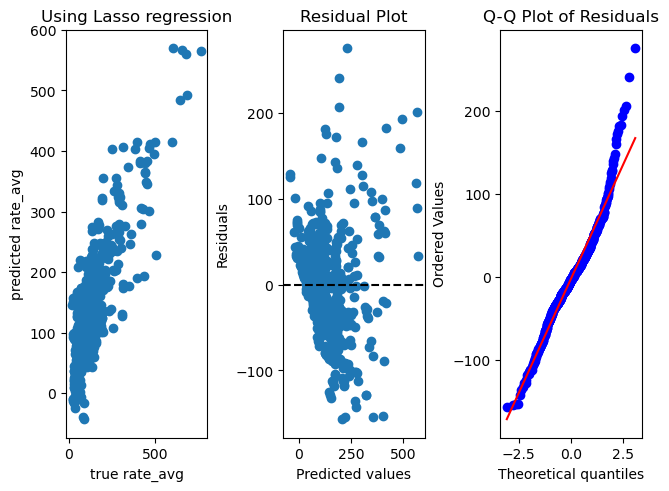

In [20]:
predict = grid_lasso.best_estimator_.predict(X_test)

from sklearn import metrics
 
print('MAE: ', metrics.mean_absolute_error(y_test, predict))
print('MSE: ', metrics.mean_squared_error(y_test, predict))
print('MAPE: ', metrics.mean_absolute_percentage_error(y_test, predict))
print('R^2: ', metrics.r2_score(y_test, predict))
print('Max Error:', metrics.max_error(y_test, predict))
print('Median Absolute Error:', metrics.median_absolute_error(y_test, predict))

mae_compare.append(metrics.mean_absolute_error(y_test, predict))
mse_compare.append(metrics.mean_squared_error(y_test, predict))
mape_compare.append(metrics.mean_absolute_percentage_error(y_test, predict))
r2_compare.append(metrics.r2_score(y_test, predict))

#show features that were put to 0 by lasso
lasso_coefs = grid_lasso.best_estimator_.named_steps['lasso'].coef_
zeroed = [col for col, coef in zip(X.columns, lasso_coefs) if coef == 0]
print(f'\nFeatures put to 0 by Lasso ({len(zeroed)}): {zeroed}')
 
fig, axs = plt.subplots(1, 3, layout="constrained")
axs[0].scatter(y_test, predict)
axs[0].set_title('Using Lasso regression')
axs[0].set_xlabel('true rate_avg')
axs[0].set_ylabel('predicted rate_avg')
 
residuals = y_test - predict
axs[1].scatter(predict, residuals)
axs[1].axhline(0, linestyle='--', color='black')
axs[1].set_xlabel('Predicted values')
axs[1].set_ylabel('Residuals')
axs[1].set_title('Residual Plot')
 
import scipy.stats as stats
stats.probplot(residuals, dist="norm", plot=axs[2])
axs[2].set_title('Q-Q Plot of Residuals')

Similar to the case of ridge regression, we can observe that large error persist between the predicted and true values (high residuals). The Q-Q also indicated that the residuals are not following a perfect normal distribution. Lasso regression lead to 17 features being zeroed out without noticeable performance improvement. 

We use bootstrap on the training set to find confidence intervals for the coefficients and the metrics.

In [21]:
from sklearn.utils import resample
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import r2_score
 
score_mse  = []
score_mae  = []
score_mape = []
score_r2   = []
n_iterations = 1000
coef_list = []
 
for i in range(n_iterations):
    #resample the TRAINING set, keep test set fixed
    X_boot, y_boot = resample(X_train_scaled, y_train, replace=True)
 
    #refit model on each bootstrap sample
    model_boot = Lasso(alpha=best_alpha, max_iter=10000)
    model_boot.fit(X_boot, y_boot)
 
    #evaluate on FIXED test set
    predict_boot = model_boot.predict(X_test_scaled)
    score_mse.append(mean_squared_error(y_test, predict_boot, squared=True))
    score_mae.append(mean_absolute_error(y_test, predict_boot))
    score_mape.append(mean_absolute_percentage_error(y_test, predict_boot))
    score_r2.append(r2_score(y_test, predict_boot))
 
    #collect coefficients
    coef_list.append(model_boot.coef_)
 
coef_array = np.array(coef_list)  #shape:(1000,n_features)
for j, col in enumerate(X.columns):
    lo = np.percentile(coef_array[:, j], 2.5)
    hi = np.percentile(coef_array[:, j], 97.5)
    print(f'{col:30s}: 95% CI [{lo:.3f}, {hi:.3f}]')  # if CI crosses 0 --> unstable feature
 
median_mse = np.median(score_mse)
lower_mse  = np.percentile(score_mse, 2.5)
upper_mse  = np.percentile(score_mse, 97.5)
 
median_mae = np.median(score_mae)
lower_mae  = np.percentile(score_mae, 2.5)
upper_mae  = np.percentile(score_mae, 97.5)
 
median_mape = np.median(score_mape)
lower_mape  = np.percentile(score_mape, 2.5)
upper_mape  = np.percentile(score_mape, 97.5)
 
median_r2 = np.median(score_r2)
lower_r2  = np.percentile(score_r2, 2.5)
upper_r2  = np.percentile(score_r2, 97.5)
 
#for coefficients (not for results):
#the further from 0 the CI, the better
#the smaller the CI, the better
print(f'\nMedian MSE:  {median_mse:.2f},  95% CI: [{lower_mse:.2f},  {upper_mse:.2f}]')
print(f'Median MAE:  {median_mae:.2f},  95% CI: [{lower_mae:.2f},  {upper_mae:.2f}]')
print(f'Median MAPE: {median_mape:.2f}, 95% CI: [{lower_mape:.2f}, {upper_mape:.2f}]')
print(f'Median R^2:  {median_r2:.2f},  95% CI: [{lower_r2:.2f},  {upper_r2:.2f}]')

photos_count                  : 95% CI [-1.793, 5.085]
superhost                     : 95% CI [-5.354, -0.387]
latitude                      : 95% CI [-0.723, 6.267]
longitude                     : 95% CI [3.416, 8.264]
guests                        : 95% CI [6.797, 20.282]
bedrooms                      : 95% CI [32.131, 46.519]
beds                          : 95% CI [0.539, 9.790]
baths                         : 95% CI [23.305, 39.279]
min_nights                    : 95% CI [-19.044, -13.128]
cleaning_fee                  : 95% CI [7.940, 14.170]
extra_guest_fee               : 95% CI [-2.405, 0.449]
num_reviews                   : 95% CI [6.721, 11.408]
rating_overall                : 95% CI [69.453, 115.140]
rating_accuracy               : 95% CI [-50.852, -14.374]
rating_checkin                : 95% CI [-49.681, -14.476]
rating_cleanliness            : 95% CI [-17.564, 2.612]
rating_communication          : 95% CI [-5.487, 28.742]
rating_location               : 95% CI [22.233, 40.

Text(0.5, 1.0, 'R^2')

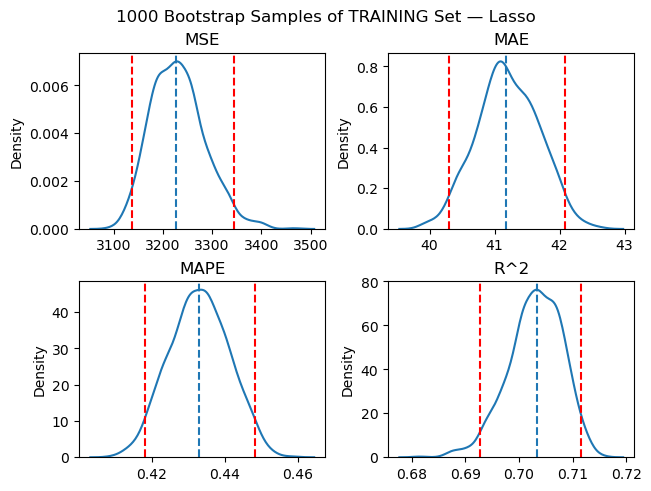

In [22]:
fig, axs = plt.subplots(2, 2, layout="constrained")
fig.suptitle('1000 Bootstrap Samples of TRAINING Set — Lasso')
# MSE
sns.kdeplot(score_mse, ax=axs[0, 0])
axs[0, 0].axvline(median_mse, linestyle="--")
axs[0, 0].axvline(lower_mse,  linestyle="--", color="red")
axs[0, 0].axvline(upper_mse,  linestyle="--", color="red")
axs[0, 0].set_title('MSE')
# MAE
sns.kdeplot(score_mae, ax=axs[0, 1])
axs[0, 1].axvline(median_mae, linestyle="--")
axs[0, 1].axvline(lower_mae,  linestyle="--", color="red")
axs[0, 1].axvline(upper_mae,  linestyle="--", color="red")
axs[0, 1].set_title('MAE')
# MAPE
sns.kdeplot(score_mape, ax=axs[1, 0])
axs[1, 0].axvline(median_mape, linestyle="--")
axs[1, 0].axvline(lower_mape,  linestyle="--", color="red")
axs[1, 0].axvline(upper_mape,  linestyle="--", color="red")
axs[1, 0].set_title('MAPE')
# R^2
sns.kdeplot(score_r2, ax=axs[1, 1])
axs[1, 1].axvline(median_r2, linestyle="--")
axs[1, 1].axvline(lower_r2,  linestyle="--", color="red")
axs[1, 1].axvline(upper_r2,  linestyle="--", color="red")
axs[1, 1].set_title('R^2')

Text(0.5, 1.0, 'Coefficient estimates with 95% CI')

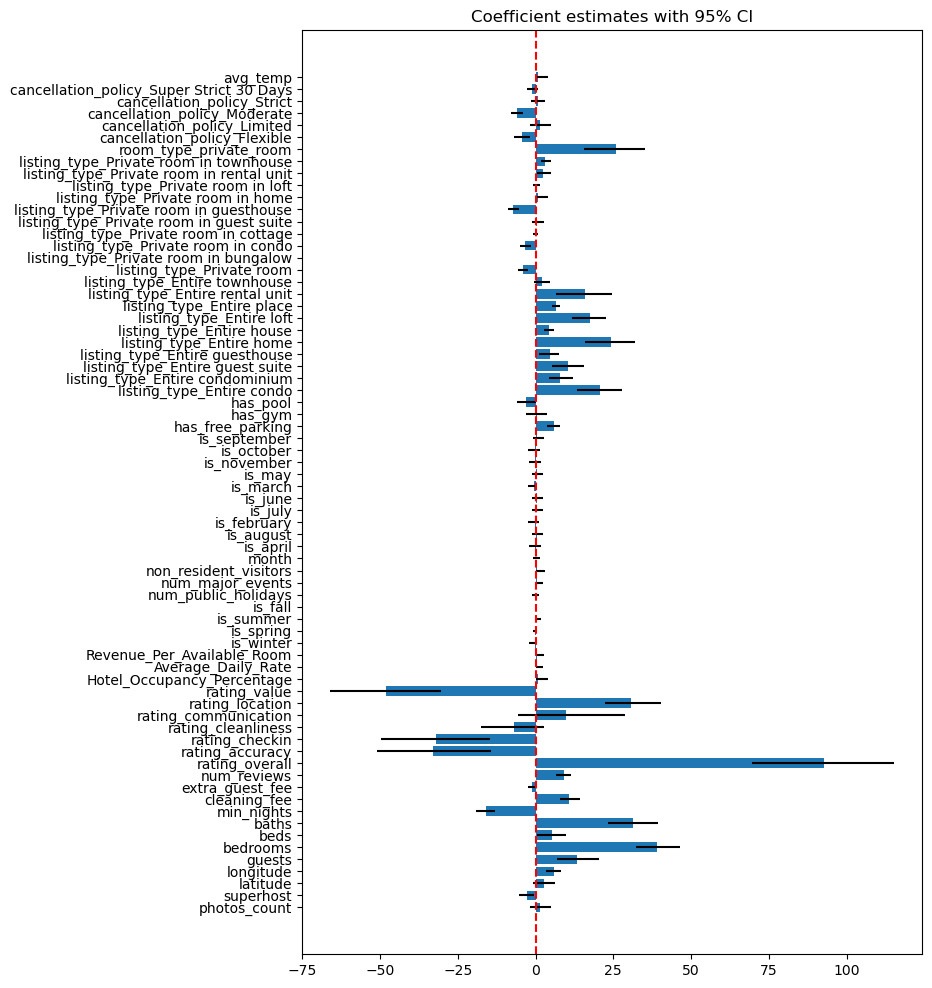

In [23]:
#coeff plot --> visualize bootstrap coefficient CIs
coef_array=np.array(coef_list)
means = coef_array.mean(axis=0)
lows  = np.percentile(coef_array,2.5,  axis=0)
highs = np.percentile(coef_array, 97.5, axis=0)

plt.figure(figsize=(8, 12))
plt.barh(X.columns, means, xerr=[np.abs(means-lows), np.abs(highs-means)])
plt.axvline(0, linestyle='--', color='red')
plt.title('Coefficient estimates with 95% CI')
#features whose CI crosses 0 = unstable/unreliable

Again, we display the CV learning curve showing the training set error and validation set error as a function of the training set size. 

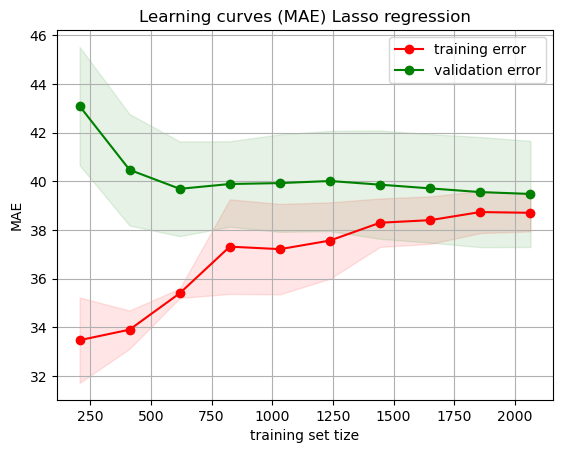

In [24]:
#CV learning curves: whether underfitting or overfitting + if more data would help
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(pipe, X_train, y_train,train_sizes=np.linspace(0.1, 1.0, 10),scoring='neg_mean_absolute_error', cv=5)
train_errors = -train_scores.mean(axis=1)
val_errors = -val_scores.mean(axis=1)

train_std = train_scores.std(axis=1)
val_std = val_scores.std(axis=1)

plt.figure()
plt.plot(train_sizes, train_errors, 'o-', color="r", label="training error")
plt.plot(train_sizes, val_errors, 'o-', color="g", label="validation error")
plt.fill_between(train_sizes, train_errors - train_std, train_errors + train_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, val_errors - val_std, val_errors + val_std, alpha=0.1, color="g")
plt.title("Learning curves (MAE) Lasso regression")
plt.xlabel("training set size")
plt.ylabel("MAE")
plt.legend(loc="best")
plt.grid(True)
plt.show()

In [25]:
#compare the results side-by-side
results = {
    'Category':  ['Baseline', 'Ridge', 'Lasso'],   
    'MAE':       mae_compare,
    'MSE':       mse_compare,
    'MAPE':      mape_compare,
    'R^2':       r2_compare
}
df = pd.DataFrame(results).set_index('Category').T
df

Category,Baseline,Ridge,Lasso
MAE,40.775617,40.769681,40.742007
MSE,3154.476996,3153.982629,3154.115133
MAPE,0.430113,0.427005,0.427719
R^2,0.710072,0.710118,0.710106


This table summarizes the results obtained using linear regression models with no feature selection, ridge regression and lasso regression. It can be observed that there is no particular improvement between the ridge/lasso models and the baseline model, even though the former should have stabilized the model, helping to tackle multicollinearity issues. Furthermore, the MAPE (~43%) means that the average prediction error lies at around 43% for all three models. This indicates that neither shrinking nor zeroing out feature coefficients has an impact on the prediction correctness. The lasso regression model zeroed out 17 features but no performance improvement was recorded. We can therefore deduce that the poor predicting performance are not due to issues with the data available, but rather due to the model used: linear regression seems to be inappropriate for this dataset. In fact, ridge and lasso regression can change the coefficients, allowing to reduce the importance of redundant features, but can not fix a model that is unsuitable for the data. R^2 plateaus at ~0.71, MAPE stays around  ~43% and the residuals don't follow a normal distribution (as can be seen on the Q-Q curves). The main source of error is bias, since the model is not flexible enough to capture the variations in the data. 

In other notebooks, we will explore different methods for predicting 'rate_avg'.